In [1]:
import tenpy.linalg.np_conserved as npc
from tenpy.networks.mpo import MPO
from tenpy.networks.mps import MPS
from tenpy.networks.site import SpinHalfSite
from tenpy.algorithms import dmrg
from tenpy.models.tf_ising import TFIChain
from tenpy.networks.mps import MPS
from tenpy.models.model import CouplingMPOModel
import numpy as np
import scipy
import matplotlib.pyplot as plt
from pprint import pprint

np.set_printoptions(precision=5, suppress=True, linewidth=100)
plt.rcParams['figure.dpi'] = 150

import tenpy
import tenpy.linalg.np_conserved as npc
from tenpy.algorithms import tebd, dmrg, tdvp
from tenpy.networks.site import SpinHalfSite, SpinSite, FermionSite
from tenpy.networks.mps import MPS
from tenpy.models.tf_ising import TFIChain
from tenpy.models.lattice import get_lattice, Lattice, HelicalLattice, _parse_sites, SimpleLattice

tenpy.tools.misc.setup_logging(to_stdout="INFO")

In [2]:
"""Basic use of the `Array` class with trivial arrays."""

M = npc.Array.from_ndarray_trivial([[0.0, 1.0], [1.0, 0.0]])
v = npc.Array.from_ndarray_trivial([2.0, 4.0 + 1.0j])
v[0] = 3.0  # set indiviual entries like in numpy
print('|v> =', v.to_ndarray())
# |v> = [ 3.+0.j  4.+1.j]

M_v = npc.tensordot(M, v, axes=[1, 0])
print('M|v> =', M_v.to_ndarray())
# M|v> = [ 4.+1.j  3.+0.j]
print('<v|M|v> =', npc.inner(v.conj(), M_v, axes='range'))
# <v|M|v> = (24+0j)

|v> = [3.+0.j 4.+1.j]
M|v> = [4.+1.j 3.+0.j]
<v|M|v> = (24+0j)


In [3]:
"""Initialization of sites, MPS and MPO."""

spin = SpinHalfSite(conserve='Sz')

N = 6  # number of sites
sites = [spin] * N  # repeat entry of list N times
pstate = ['up', 'down'] * (N // 2)  # Neel state
psi = MPS.from_product_state(sites, pstate, bc='finite', unit_cell_width=N)
print('<Sz> =', psi.expectation_value('Sz'))
# <Sz> = [ 0.5 -0.5  0.5 -0.5  0.5 -0.5]
print('<Sp_i Sm_j> =', psi.correlation_function('Sp', 'Sm'), sep='\n')
# <Sp_i Sm_j> =
# [[1. 0. 0. 0. 0. 0.]
#  [0. 0. 0. 0. 0. 0.]
#  [0. 0. 1. 0. 0. 0.]
#  [0. 0. 0. 0. 0. 0.]
#  [0. 0. 0. 0. 1. 0.]
#  [0. 0. 0. 0. 0. 0.]]

# define an MPO
Id, Sp, Sm, Sz = spin.Id, spin.Sp, spin.Sm, spin.Sz
J, Delta, hz = 1.0, 1.0, 0.2
W_bulk = [
    [Id, Sp, Sm, Sz, -hz * Sz],
    [None, None, None, None, 0.5 * J * Sm],
    [None, None, None, None, 0.5 * J * Sp],
    [None, None, None, None, J * Delta * Sz],
    [None, None, None, None, Id],
]
W_first = [W_bulk[0]]  # first row
W_last = [[row[-1]] for row in W_bulk]  # last column
Ws = [W_first] + [W_bulk] * (N - 2) + [W_last]
H = MPO.from_grids([spin] * N, Ws, bc='finite', IdL=0, IdR=-1, mps_unit_cell_width=N)
print('<psi|H|psi> =', H.expectation_value(psi))
# <psi|H|psi> = -1.25

<Sz> = [ 0.5 -0.5  0.5 -0.5  0.5 -0.5]
<Sp_i Sm_j> =
[[1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0.]]
<psi|H|psi> = -1.25


In [20]:
"""Call of infinite DMRG."""

N = 2  # number of sites in unit cell
model = TFIChain({'L': N, 'J': 1.0, 'g': 1.1, 'bc_MPS': 'infinite'})
sites = model.lat.mps_sites()
psi = MPS.from_product_state(sites, ['up'] * N, 'infinite', unit_cell_width=N)
dmrg_params = {'trunc_params': {'chi_max': 100, 'svd_min': 1.0e-10}, 'mixer': True}
info = dmrg.run(psi, model, dmrg_params)
print('E =', info['E'])
# E = -1.342864022725017
print('max. bond dimension =', max(psi.chi))
# max. bond dimension = 56
print('corr. length =', psi.correlation_length())
# corr. length = 4.915809146764157

INFO    : TFIChain: reading 'bc_MPS'='infinite'
INFO    : TFIChain: reading 'L'=2
INFO    : TFIChain: reading 'J'=1.0


INFO    : TFIChain: reading 'g'=1.1
INFO    : DMRG: subconfig 'trunc_params'=Config(<2 options>, 'trunc_params')
INFO    : start environment_sweep
INFO    : trunc_params: reading 'chi_max'=100
INFO    : trunc_params: reading 'svd_min'=1e-10
INFO    : DMRG: reading 'mixer'=True
INFO    : activate DensityMatrixMixer with initial amplitude 1e-05
INFO    : Running sweep with optimization
INFO    : start environment_sweep
INFO    : checkpoint after sweep 10
energy=-1.3428640227250703, max S=0.3288610607748503, age=128, norm_err=9.9e-09
Current memory usage 178.2MB, wall time: 1.4s
Delta E = nan, Delta S = 3.2886e-02 (per sweep)
max trunc_err = 6.6519e-20, max E_trunc = 1.4211e-14
chi: [60, 60]
INFO    : Running sweep with optimization
INFO    : start environment_sweep
INFO    : checkpoint after sweep 20
energy=-1.3428640227250881, max S=0.3288583713048053, age=248, norm_err=9.8e-14
Current memory usage 178.2MB, wall time: 1.5s
Delta E = -1.7764e-15, Delta S = -2.6805e-07 (per sweep)
max tru

In [16]:
model_params = {
    'L': 2,
    #transverse field:
    'g': 1.0,
    'bc_MPS': 'infinite',
    'conserve': 'best'
}
model = TFIChain(model_params)
# you can now print the default parameters used:
print("used parameters, including default/not specified ones:")
pprint(model_params)

INFO    : TFIChain: reading 'conserve'='best'
INFO    : TFIChain: set conserve to parity
INFO    : TFIChain: reading 'bc_MPS'='infinite'
INFO    : TFIChain: reading 'L'=2
INFO    : TFIChain: reading 'g'=1.0
used parameters, including default/not specified ones:
{'J': 1.0,
 'L': 2,
 'bc_MPS': 'infinite',
 'bc_x': 'periodic',
 'conserve': 'best',
 'explicit_plus_hc': False,
 'g': 1.0,
 'helical_lattice': None,
 'irregular_remove': None,
 'lattice': <class 'tenpy.models.lattice.Chain'>,
 'order': 'default',
 'sort_charge': True,
 'sort_mpo_legs': False}


In [17]:
p_state = ['up', 'down'] * (model.lat.N_sites//2)
psi = MPS.from_product_state(model.lat.mps_sites(), p_state, bc=model.lat.bc_MPS)
print("<sigmaz> = ", psi.expectation_value('Sigmaz'))
print("S = ", psi.entanglement_entropy())
E = model.bond_energies(psi)
print("energy Neel:", E)

  super().__init__(sites, bc, unit_cell_width)

<sigmaz> =  [ 1. -1.]
S =  [-0. -0.]
energy Neel: [0. 0.]


In [18]:
p_state = ['up'] * model.lat.N_sites
psi = MPS.from_product_state(model.lat.mps_sites(), p_state, bc=model.lat.bc_MPS, unit_cell_width=model.lat.mps_unit_cell_width)
algorithm_params = {
    'trunc_params': {
        'chi_max': 30,
        'svd_min': 1.e-7,
    },
    'max_sweeps': 40,
}
E, psi = dmrg.run(psi, model, algorithm_params)
print(E)

INFO    : TwoSiteDMRGEngine: subconfig 'trunc_params'=Config(<2 options>, 'trunc_params')


INFO    : start environment_sweep
INFO    : trunc_params: reading 'chi_max'=30
INFO    : trunc_params: reading 'svd_min'=1e-07
INFO    : TwoSiteDMRGEngine: reading 'max_sweeps'=40
INFO    : Running sweep with optimization
INFO    : start environment_sweep
INFO    : checkpoint after sweep 10
energy=-1.2732297890100277, max S=0.5971035593475743, age=128, norm_err=1.1e-03
Current memory usage 178.2MB, wall time: 0.6s
Delta E = nan, Delta S = 5.9652e-02 (per sweep)
max trunc_err = 1.7558e-13, max E_trunc = 1.1937e-12
chi: [30, 30]
INFO    : Running sweep with optimization
INFO    : start environment_sweep
INFO    : checkpoint after sweep 20
energy=-1.2732371980492516, max S=0.6572441211091861, age=248, norm_err=6.3e-04
Current memory usage 178.2MB, wall time: 0.6s
Delta E = -7.4090e-07, Delta S = 6.0398e-03 (per sweep)
max trunc_err = 1.5790e-11, max E_trunc = 1.0857e-10
chi: [30, 30]
INFO    : Running sweep with optimization
INFO    : start environment_sweep
INFO    : checkpoint after swe

INFO    : SpinModel: reading 'lattice'='Honeycomb'
INFO    : SpinModel: reading 'S'=0.5
INFO    : SpinModel: reading 'conserve'='Sz'
INFO    : SpinModel: reading 'bc_MPS'='infinite'
INFO    : SpinModel: reading 'order'='Cstyle'
INFO    : SpinModel: reading 'Lx'=2
INFO    : SpinModel: reading 'Ly'=2
INFO    : SpinModel: reading 'bc_y'='cylinder'
INFO    : SpinModel: reading 'Jx'=1.0
INFO    : SpinModel: reading 'Jy'=1.0
INFO    : SpinModel: reading 'Jz'=1.0
0.50000 * Sm_0 Sp_1 +
0.50000 * Sm_0 Sp_3 +
0.50000 * Sp_0 Sm_1 +
0.50000 * Sp_0 Sm_3 +
1.00000 * Sz_0 Sz_1 +
1.00000 * Sz_0 Sz_3 +
0.50000 * Sm_1 Sp_2 +
0.50000 * Sm_1 Sp_4 +
0.50000 * Sp_1 Sm_2 +
0.50000 * Sp_1 Sm_4 +
1.00000 * Sz_1 Sz_2 +
1.00000 * Sz_1 Sz_4 +
0.50000 * Sm_2 Sp_3 +
0.50000 * Sp_2 Sm_3 +
1.00000 * Sz_2 Sz_3 +
0.50000 * Sm_3 Sp_6 +
0.50000 * Sp_3 Sm_6 +
1.00000 * Sz_3 Sz_6 +
0.50000 * Sm_4 Sp_5 +
0.50000 * Sm_4 Sp_7 +
0.50000 * Sp_4 Sm_5 +
0.50000 * Sp_4 Sm_7 +
1.00000 * Sz_4 Sz_5 +
1.00000 * Sz_4 Sz_7 +
0.50000 * S

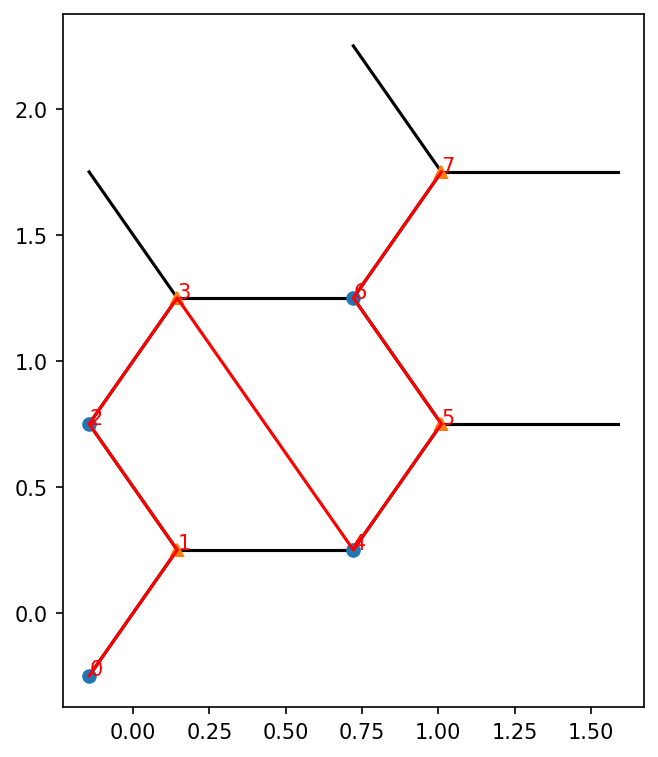

INFO    : DMRG: subconfig 'trunc_params'=Config(<2 options>, 'trunc_params')
INFO    : start environment_sweep
INFO    : trunc_params: reading 'chi_max'=100
INFO    : trunc_params: reading 'svd_min'=1e-10
INFO    : DMRG: reading 'mixer'=True
INFO    : activate DensityMatrixMixer with initial amplitude 1e-05
INFO    : DMRG: reading 'max_sweeps'=40
INFO    : Running sweep with optimization
INFO    : start environment_sweep
INFO    : checkpoint after sweep 10
energy=-0.5616894385390818, max S=1.2818509536152829, age=264, norm_err=6.0e-03
Current memory usage 329.7MB, wall time: 8.1s
Delta E = nan, Delta S = 1.1186e-01 (per sweep)
max trunc_err = 4.5838e-07, max E_trunc = 1.1873e-06
chi: [100, 100, 100, 100, 100, 100, 100, 100]
INFO    : Running sweep with optimization
INFO    : start environment_sweep
INFO    : checkpoint after sweep 20
energy=-0.5617008032153521, max S=1.2898464804750516, age=504, norm_err=6.0e-04
Current memory usage 331.3MB, wall time: 3.3s
Delta E = -1.1365e-06, Delta

In [11]:
"""Initialization of the Heisenberg model on a lattice."""

from tenpy.models.spins import SpinModel

model_params = {
    'S': 0.5,  # Spin 1/2
    'lattice': 'Honeycomb',
    'bc_MPS': 'infinite',
    'bc_y': 'cylinder',
    "Lx": 2,
    'Ly': 2,  # defines cylinder circumference
    'conserve': 'Sz',  # use Sz conservation
    'Jx': 1.0,
    "order": "Cstyle",
    'Jy': 1.0,
    'Jz': 1.0,  # Heisenberg coupling
}
model = SpinModel(model_params)

print(model.all_coupling_terms().to_TermList() + model.all_onsite_terms().to_TermList())

#display lattice and chain
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 6))
ax = plt.gca()
model.lat.plot_coupling(ax)
model.lat.plot_sites(ax)
model.lat.plot_order(ax)
plt.show()

N = 8  # number of sites in unit cell
sites = model.lat.mps_sites() # create sites
psi = MPS.from_product_state(sites, ['up', 'down'] * (N//2), 'infinite', unit_cell_width=N) # create MPS
dmrg_params = {'trunc_params': {'chi_max': 100, 'svd_min': 1.0e-10}, 'mixer': True, 'max_sweeps': 40}
info = dmrg.run(psi, model, dmrg_params) #E, psi
print('E =', info['E'])

In [78]:
"""
plot_surface.py
---------------
Takes a list of [x, y] points and corresponding E values, then renders
a 3-D surface (via interpolation onto a regular grid) with color grading
that maps to the height (E value).

Usage
-----
    # As a script — runs the built-in demo
    python plot_surface.py

    # As an imported function
    from plot_surface import plot_energy_surface
    plot_energy_surface(points=[[0,0],[1,0],[0,1],[1,1]], E_values=[0,1,1,2])
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D          # noqa: F401 (registers 3-D projection)
from scipy.interpolate import griddata


def plot_energy_surface(
    points: list,
    E_values: list,
    title: str = "Energy Surface",
    colormap: str = "plasma",
    grid_resolution: int = 150,
    interpolation_method: str = "cubic",
    show_scatter: bool = True,
    save_path: str | None = "energy_surface.png",
    figsize: tuple = (6, 4),
    dpi: int = 100,
) -> plt.Figure:
    """
    Plot scalar E values as a color-graded 3-D surface above the x-y plane.

    Parameters
    ----------
    points : list of [x, y]
        Scattered (x, y) coordinates, shape (N, 2).
    E_values : list of float
        Scalar value at each point, length N.
    title : str
        Figure title.
    colormap : str
        Any valid Matplotlib colormap name ('plasma', 'viridis', 'inferno', …).
    grid_resolution : int
        Number of grid cells along each axis used for interpolation.
    interpolation_method : str
        Passed to scipy.interpolate.griddata: 'cubic', 'linear', or 'nearest'.
    show_scatter : bool
        Overlay the original data points on the surface.
    save_path : str or None
        File path to save the figure; set to None to skip saving.
    figsize : tuple of (width, height)
        Figure size in inches. Default (6, 4) is compact for Jupyter notebooks.
    dpi : int
        Dots per inch. Jupyter renders figures at screen DPI, so lowering this
        directly shrinks the displayed size. Default 100.

    Returns
    -------
    matplotlib.figure.Figure
    """
    # ── Validate inputs ──────────────────────────────────────────────────────
    points = np.asarray(points, dtype=float)
    E_values = np.asarray(E_values, dtype=float)

    if points.ndim != 2 or points.shape[1] != 2:
        raise ValueError(f"`points` must have shape (N, 2), got {points.shape}.")
    if E_values.ndim != 1 or len(E_values) != len(points):
        raise ValueError(
            f"`E_values` must be a 1-D array with the same length as `points`."
            f" Got {E_values.shape} vs {len(points)} points."
        )

    x, y = points[:, 0], points[:, 1]
    E = E_values

    # ── Interpolate scattered data onto a regular grid ───────────────────────
    xi = np.linspace(x.min(), x.max(), grid_resolution)
    yi = np.linspace(y.min(), y.max(), grid_resolution)
    Xi, Yi = np.meshgrid(xi, yi)
    Zi = griddata((x, y), E, (Xi, Yi), method=interpolation_method)

    # ── Color normalization (shared by surface + colorbar) ───────────────────
    e_min, e_max = np.nanmin(Zi), np.nanmax(Zi)
    norm = plt.Normalize(vmin=e_min, vmax=e_max)
    cmap = cm.get_cmap(colormap)

    # ── Figure / axes ────────────────────────────────────────────────────────
    fig = plt.figure(figsize=figsize, dpi=dpi)
    ax = fig.add_subplot(111, projection="3d")
    fig.patch.set_facecolor("#0e0e14")
    ax.set_facecolor("#0e0e14")

    # ── Surface ──────────────────────────────────────────────────────────────
    surf = ax.plot_surface(
        Xi, Yi, Zi,
        facecolors=cmap(norm(Zi)),
        linewidth=0,
        antialiased=True,
        alpha=0.93,
        shade=False,
    )

    # ── Original data-point scatter ──────────────────────────────────────────
    if show_scatter:
        ax.scatter(
            x, y, E,
            c=E,
            cmap=colormap,
            norm=norm,
            s=30,
            edgecolors="white",
            linewidths=0.4,
            zorder=6,
            label="Input points",
            depthshade=False,
        )
        ax.legend(
            facecolor="#1a1a2e",
            edgecolor="#444",
            labelcolor="white",
            fontsize=10,
            loc="upper left",
        )

    # ── Colorbar ─────────────────────────────────────────────────────────────
    mappable = cm.ScalarMappable(cmap=colormap, norm=norm)
    mappable.set_array(E)
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, pad=0.08, aspect=20)
    cbar.set_label("E value", color="white", fontsize=12)
    cbar.ax.yaxis.set_tick_params(color="white")
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")
    cbar.outline.set_edgecolor("#555")

    # ── Axes styling ─────────────────────────────────────────────────────────
    label_kw = dict(color="white", fontsize=12, labelpad=10)
    ax.set_xlabel("Jp", **label_kw)
    ax.set_ylabel("Jz", **label_kw)
    ax.set_zlabel("E", **label_kw)
    ax.set_title(title, color="white", fontsize=14, fontweight="bold", pad=18)

    for spine in [ax.xaxis, ax.yaxis, ax.zaxis]:
        spine.pane.fill = False
        spine.pane.set_edgecolor("#333")
        spine._axinfo["grid"]["color"] = "#2a2a3a"
        spine.set_tick_params(colors="white")

    ax.view_init(elev=28, azim=-55)

    # ── Save & show ──────────────────────────────────────────────────────────
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
        print(f"Saved → {save_path}")
    plt.show()
    return fig

In [2]:
#my stuff
class AnisotropicHeisenberg(CouplingMPOModel):
    #model_params: lat_type; Jz; Jp; order; Lx; Ly; bc_x; bc_y
    #basis states spin_up = [1, 0]; spin_down = [0, 1]

    def init_sites(self, model_params):
        #we are conserving a U(1) quantity (called Sz)
        #basis state 1 (spin up) has "charge" 1, down has -1

        charge_info = npc.ChargeInfo([1], ['Sz'])
        ch = npc.LegCharge.from_qflat(charge_info, [1,-1])

        #define local operators manually and label the cols/rows with their charge
        Sz = npc.Array.from_ndarray([[0.5, 0.0], [0.0, -0.5]], [ch, ch.conj()])
        Sp = npc.Array.from_ndarray([[0.0, 1.0], [0.0, 0.0]], [ch, ch.conj()])
        Sm = npc.Array.from_ndarray([[0.0, 0.0], [1.0, 0.0]], [ch, ch.conj()])

        #create the site
        site = tenpy.networks.site.Site(ch, ["up", "down"], Sz = Sz, Sp = Sp, Sm = Sm)
        return site
    
    def init_lattice(self, model_params):
        #get the class of the lattice type
        lat_type = model_params.get("lat_type", "Square")
        if not isinstance(lat_type, str):
            raise TypeError("Lattice type must be a string")
        
        LatticeClass = get_lattice(lattice_name = lat_type)
        if not LatticeClass.dim == 2:
            raise Exception("Lattice must be 2D")
        
        #order = the way we wind the 1D chain around the 2D lattice
        order = model_params.get("order", "Cstyle")

        sites = self.init_sites(model_params)

        #Do iDMRG
        bc_MPS = model_params.get("bc_MPS", "infinite")
        #open, periodic
        bc_x = model_params.get("bc_x", "periodic")
        #default = periodic for infinite DMRG
        bc_y = model_params.get("bc_y", "periodic")
        #how we wind the chain around the 2D lattice
        order = model_params.get("order", "Cstyle")

        #dimensions
        #length of unit cell in x direction
        Lx = model_params.get('Lx', 1)
        #cylinder width
        Ly = model_params.get('Ly', 4)
        
        lat = LatticeClass(Lx, Ly, sites, bc = [bc_x, bc_y], order = order, bc_MPS = bc_MPS)
        return lat
    
    def init_terms(self, model_params):
        #z and in plane couplings
        Jz = model_params.get("Jz", 1.0)
        Jp = model_params.get("Jp", 1.0)

        #add couplings to hamiltonian
        for u1, u2, dx in self.lat.pairs['nearest_neighbors']:
            #Jz*Sz_1*Sz_2
            self.add_coupling(Jz, u1, 'Sz', u2, 'Sz', dx)
            #Jp*0.5* (S+_1 S-_2 + h.c.)
            self.add_coupling(.5 * Jp, u1, 'Sp', u2, 'Sm', dx, plus_hc=True)

In [ ]:
def run(Jp_list, Jz_list):
    model_params = {'lat_type': 'Triangular', 'Lx': 2, 'Ly': 4, 'Jz': 1.0, 'Jp': 1.0, "bc_MPS": "infinite", "bc_x": "periodic", "bc_y": -1}
    dmrg_params = {'trunc_params': {'chi_max': 100, 'svd_min': 1.0e-10}, 'mixer': True, 'max_sweeps': 40}
    N = 4  # number of sites in unit cell
    
    #model_params: lat_type; J; g; order; Lx; Ly;
    model = AnisotropicHeisenberg(model_params)
    sites = model.lat.mps_sites() # create sites

    #display lattice and chain
    import matplotlib.pyplot as plt
    plt.figure(figsize=(5, 6))
    ax = plt.gca()
    model.lat.plot_coupling(ax)
    model.lat.plot_sites(ax)
    model.lat.plot_order(ax)
    plt.show()

    psi = MPS.from_product_state(sites, ['up', 'down'] * (N//2), 'infinite', unit_cell_width=N) # create MPS

    engine = dmrg.TwoSiteDMRGEngine(psi, model, dmrg_params)


    np.set_printoptions(linewidth=120)
    E_arr = []
    corr_function_zz = []
    corr_function_zx = []
    corr_function_xx = []
    J_arr = []
    for Jz in Jz_list:
        for Jp in Jp_list:
            if Jz == 0 and Jp == 0:
                continue
            print('-' * 80)
            print(f'{Jz=:.4f}')
            print('-' * 80)
            model_params['Jz'] = Jz
            model_params['Jp'] = Jp
            model = AnisotropicHeisenberg(model_params)
            engine.init_env(model=model)  # (re)initialize DMRG environment with new model
            # this uses the result from the previous DMRG as first initial guess
            info = engine.run()
            J_arr.append([Jp, Jz])
            E_arr.append(info[0])
            # psi is modified by engine.run() and now represents the ground state for the current `Jz`.
            corr_function_zz.append(psi.correlation_function('Sz', 'Sz', range(10), range(10))[0])
            corr_zp = psi.correlation_function('Sz', 'Sp', range(10), range(10))
            corr_zm = psi.correlation_function('Sz', 'Sm', range(10), range(10))
            corr_pm = psi.correlation_function('Sp', 'Sm', range(10), range(10))
            corr_mp = psi.correlation_function('Sm', 'Sp', range(10), range(10))
            corr_function_zx.append([sum(x)/2.0 for x in zip(corr_zp[i], corr_zm[i])] for i in range((len(corr_zp))))
            corr_function_xx.append([sum(x)/2.0 for x in zip(corr_pm[i], corr_mp[i])] for i in range((len(corr_pm))))
            dmrg_params['start_env'] = 0  # (some of) the parameters are read out again

    return J_arr, E_arr, corr_function_zz, corr_function_zx, corr_function_xx

INFO    : AnisotropicHeisenberg: reading 'lat_type'='Triangular'
INFO    : AnisotropicHeisenberg: reading 'bc_MPS'='infinite'
INFO    : AnisotropicHeisenberg: reading 'bc_x'='periodic'
INFO    : AnisotropicHeisenberg: reading 'bc_y'=-1
INFO    : AnisotropicHeisenberg: reading 'Lx'=2
INFO    : AnisotropicHeisenberg: reading 'Ly'=2
INFO    : AnisotropicHeisenberg: reading 'Jz'=1.0
INFO    : AnisotropicHeisenberg: reading 'Jp'=1.0


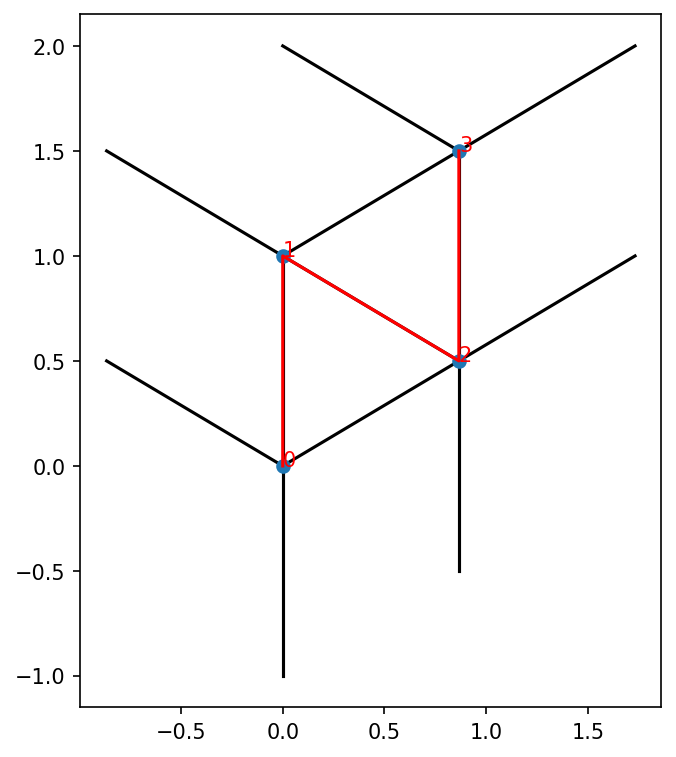

INFO    : TwoSiteDMRGEngine: subconfig 'trunc_params'=Config(<2 options>, 'trunc_params')
INFO    : start environment_sweep
INFO    : trunc_params: reading 'chi_max'=100
INFO    : trunc_params: reading 'svd_min'=1e-10
--------------------------------------------------------------------------------
Jz=1.0000
--------------------------------------------------------------------------------
INFO    : AnisotropicHeisenberg: reading 'explicit_plus_hc'=False
INFO    : AnisotropicHeisenberg: reading 'lat_type'='Triangular'
INFO    : AnisotropicHeisenberg: reading 'order'='Cstyle'
INFO    : AnisotropicHeisenberg: reading 'bc_MPS'='infinite'
INFO    : AnisotropicHeisenberg: reading 'bc_x'='periodic'
INFO    : AnisotropicHeisenberg: reading 'bc_y'=-1
INFO    : AnisotropicHeisenberg: reading 'Lx'=2
INFO    : AnisotropicHeisenberg: reading 'Ly'=2
INFO    : AnisotropicHeisenberg: reading 'Jz'=1.0
INFO    : AnisotropicHeisenberg: reading 'Jp'=0.0
INFO    : AnisotropicHeisenberg: reading 'sort_mpo_leg

In [133]:
Jz_list = np.linspace(-0.5, 0.5, 10)
Jp_list = np.linspace(-0.5, 0.5, 10)

J_arr, E_arr, corr_function_zz, corr_function_zx, corr_function_xx = run(Jp_list, Jz_list)
print(corr_function_zz)

In [100]:
plot_energy_surface(
    points=J_arr,
    E_values=E_arr,
    title="Energy",
    colormap="plasma",
    interpolation_method = "linear",
)
print(corr_function_zz)
corr_function_zz_01 = []
corr_function_zx_01 = []
for row in corr_function_zz:
    corr_function_zz_01.append(row[2])
for row in corr_function_zx:
    corr_function_zx_01.append(row[2])
corr_function_xx_01 = []
for row in corr_function_xx:
    corr_function_xx_01.append(row[2])
plot_energy_surface(
    points=J_arr,
    E_values=corr_function_zz_01,
    title="Correlation function zz",
    colormap="plasma",
    interpolation_method = "linear",
)
plot_energy_surface(
    points=J_arr,
    E_values=corr_function_zx_01,
    title="Correlation function zx",
    colormap="plasma",
    interpolation_method = "linear",
)
plot_energy_surface(
    points=J_arr,
    E_values=corr_function_xx_01,
    title="Correlation function xx",
    colormap="plasma",
    interpolation_method = "linear",
)

[array([ 0.25, -0.  ,  0.  , -0.  ])]


QhullError: QH6214 qhull input error: not enough points(1) to construct initial simplex (need 4)

While executing:  | qhull d Qz Qc Qt Qbb Q12
Options selected for Qhull 2019.1.r 2019/06/21:
  run-id 114594649  delaunay  Qz-infinity-point  Qcoplanar-keep  Qtriangulate
  Qbbound-last  Q12-allow-wide  _pre-merge  _zero-centrum  Qinterior-keep
  _maxoutside  0


To change between DMRG and iDMRG, must change bc_MPS in model and change "finite" to "infinite" in the state as well.
To run a job on a cluster, use simulations
Use "conserve" = "best"
You can put multiple operator names separated by whitespace to represent the product of these operators
Test model by printing out connections
The “optimal” ordering can not be known a priori and might even depend on your coupling parameters, so test a few maybe?
For boundary conditions bc, can be open or periodic and determines whether or not there should be periodic couplings added in the corresponding directions 
For an 'infinite' MPS, the whole lattice is repeated in the direction of the first basis vector of the lattice. For bc_MPS='infinite', the first direction should always be 'periodic', but you can also define a lattice with bc_MPS='finite', bc=['periodic', 'periodic'] for a finite system on the torus. This is discouraged, though, because the ground state MPS will require the squared bond dimension for the same precision in this case!
can use irregular lattice to remove certain sites if desired
Troubleshooting: change the size and shape of the MPS unit cell (where possible), in case an artificially enforced translational invariance prevents the algorithm from finding a true ground state which is incommensurate with this periodicity. For example, a chain system which has a true ground state that is periodic in three sites, will not be accurately represented by a two-site MPS unit cell, as the latter enforces two-site periodicity.
the mixer prevents getting stuck in a local minimum, setting it to True just uses the default

for yaml file:
lat_product_state uses MPS.from_lat_product_state(), which expects the state specified in lattice coordinates (hence the nested list structure like [[up], [down]] for a unit cell).
product_state uses MPS.from_product_state() directly, which takes a flat list of states in MPS site order — exactly like your Python code.
The unit_cell_width: 2 is the YAML equivalent of passing unit_cell_width=N (with N=2), which tells TeNPy that the MPS unit cell is 2 sites wide for the infinite boundary conditions.
Note that the bc='infinite' part is not set here — that comes from your model's bc_MPS parameter (typically set in model_params), which the InitialStateBuilder reads automatically from the simulation context.

In [134]:
Sp = np.array([[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],       [1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],       [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j]])
Sm = np.array([[0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],       [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]])
Sz = np.array([[-1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],       [ 0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j],       [ 0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j],       [ 0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j]])

ChiX = np.array([[0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],       [1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],       [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],       [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j]])
ChiY = np.array([[0.+0.j, 0.+1.j, 0.+0.j, 0.+0.j],       [0.-1.j, 0.+0.j, 0.+0.j, 0.+0.j],       [0.+0.j, 0.+0.j, 0.+0.j, 0.+1.j],       [0.+0.j, 0.+0.j, 0.-1.j, 0.+0.j]])
ChiZ = np.array([[-1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],       [ 0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j],       [ 0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j],       [ 0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j]])

SzChiX = np.array([[ 0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j],       [-1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],       [ 0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j],       [ 0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j]])
SzChiY = np.array([[ 0.+0.j, -0.-1.j,  0.+0.j,  0.+0.j],       [ 0.+1.j,  0.+0.j,  0.+0.j,  0.+0.j],       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+1.j],       [ 0.+0.j,  0.+0.j,  0.-1.j,  0.+0.j]])
SzChiZ = np.array([[ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],       [ 0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j],       [ 0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j],       [ 0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j]])

SpChiX = np.array([[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],       [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],       [1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]])
SpChiY = np.array([[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],       [0.+0.j, 0.+1.j, 0.+0.j, 0.+0.j],       [0.-1.j, 0.+0.j, 0.+0.j, 0.+0.j]])
SpChiZ = np.array([[ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],       [-1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],       [ 0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j]])

SmChiX = np.array([[0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],       [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]])
SmChiY = np.array([[0.+0.j, 0.+0.j, 0.+0.j, 0.+1.j],       [0.+0.j, 0.+0.j, 0+-1.j, 0.+0.j],       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]])
SmChiZ = np.array([[ 0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j],       [ 0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j],       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j]])

ChiP = np. array([[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],[1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],[0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j]])
ChiM = np. array([[0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],[0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]])
SzChiP = np. array([[ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],[-1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],[ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],[ 0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j]])
SzChiM = np. array([[ 0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j],[ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],[ 0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j],[ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j]])
SpChiP = np. array([[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],[1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]])
SpChiM = np. array([[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],[0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]])
SmChiP = np. array([[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],[0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]])
SmChiM = np. array([[0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]])

print(Sp)


[[0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]]


In [3]:
class ModTriangular(SimpleLattice):
    """Copied from the tenpy but changed basis"""
    dim = 2  #: the dimension of the lattice

    def __init__(self, Lx, Ly, site, **kwargs):
        sqrt3_half = 0.5 * np.sqrt(3)  # = cos(pi/6)
        basis = np.array([[1.0, 0], [0.5,  sqrt3_half]])
        NN = [(0, 0, np.array([1, 0])), (0, 0, np.array([-1, 1])), (0, 0, np.array([0, -1]))]
        nNN = [(0, 0, np.array([2, -1])), (0, 0, np.array([1, 1])), (0, 0, np.array([-1, 2]))]
        nnNN = [(0, 0, np.array([2, 0])), (0, 0, np.array([0, 2])), (0, 0, np.array([-2, 2]))]
        kwargs.setdefault('basis', basis)
        kwargs.setdefault('pairs', {})
        kwargs['pairs'].setdefault('nearest_neighbors', NN)
        kwargs['pairs'].setdefault('next_nearest_neighbors', nNN)
        kwargs['pairs'].setdefault('next_next_nearest_neighbors', nnNN)
        SimpleLattice.__init__(self, [Lx, Ly], site, **kwargs)

INFO    : AnisotropicHeisenberg: reading 'lat_type'='ModTriangular'


INFO    : AnisotropicHeisenberg: reading 'bc_MPS'='infinite'
INFO    : AnisotropicHeisenberg: reading 'bc_x'='periodic'
INFO    : AnisotropicHeisenberg: reading 'bc_y'=-1
INFO    : AnisotropicHeisenberg: reading 'Lx'=4
INFO    : AnisotropicHeisenberg: reading 'Ly'=3
INFO    : AnisotropicHeisenberg: reading 'Jz'=1.0
INFO    : AnisotropicHeisenberg: reading 'Jp'=1.0


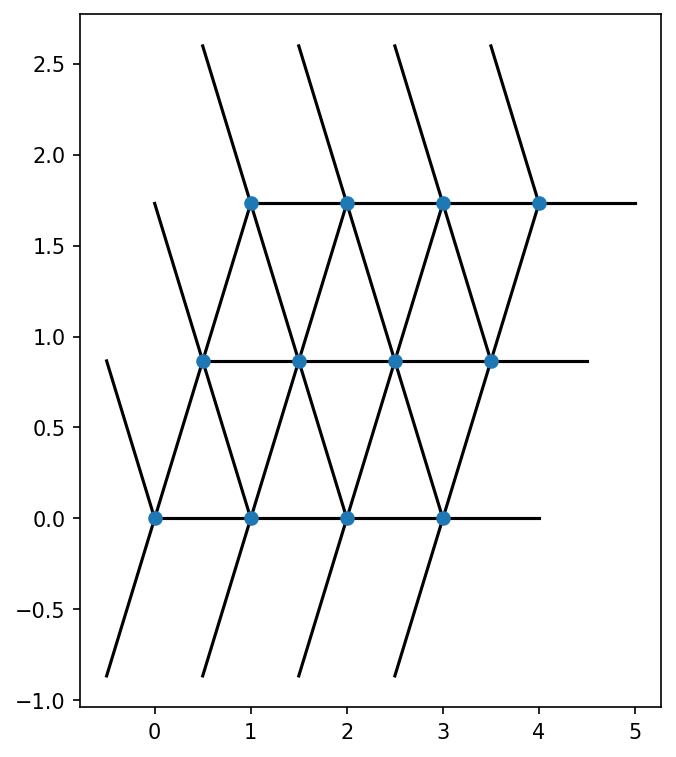

[[1.      0.     ]
 [0.5     0.86603]]
Bond directions in your lattice:
  u1=0, u2=0, dx=[1 0]  →  angle=0.0°  1.0
  u1=0, u2=0, dx=[-1  1]  →  angle=120.0°  (-0.49999999999999983+0.8660254037844387j)
  u1=0, u2=0, dx=[ 0 -1]  →  angle=-120.0°  (-0.5000000000000002-0.8660254037844384j)


In [22]:
#model_params: lat_type; J; g; order; Lx; Ly;
model_params = {'lat_type': 'ModTriangular', 'Lx': 4, 'Ly': 3, 'Jz': 1.0, 'Jp': 1.0, "bc_MPS": "infinite", "bc_x": "periodic", "bc_y": -1}
model = AnisotropicHeisenberg(model_params)
sites = model.lat.mps_sites() # create sites

#display lattice and chain
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 6))
ax = plt.gca()
model.lat.plot_coupling(ax)
model.lat.plot_sites(ax)
#model.lat.plot_order(ax)
plt.show()

def angle_of_bond(lat, u1, u2, dx):
    """Returns the angle in degrees of a bond (u1, u2, dx)."""
    pos1 = lat.unit_cell_positions[u1]
    pos2 = lat.unit_cell_positions[u2]

    # Absolute position difference including unit cell shift
    delta = pos2 - pos1 + dx @ lat.basis  # lat.basis are the lattice vectors

    angle = np.degrees(np.arctan2(delta[1], delta[0]))  # mod 180: bond has no direction
    return angle

print(model.lat.basis)
phases = {0.0: 1.0, 120.0: np.exp(2*np.pi*1.j / 3.0 ), -120.0: (np.exp(2*np.pi*1.j / 3.0 ))**2}
print("Bond directions in your lattice:")
for u1, u2, dx in model.lat.pairs['nearest_neighbors']:
    angle = angle_of_bond(model.lat, u1, u2, dx)
    pos1 = model.lat.unit_cell_positions[u1]
    pos2 = model.lat.unit_cell_positions[u2] + dx @ model.lat.basis
    print(f"  u1={u1}, u2={u2}, dx={dx}  →  angle={angle:.1f}°  {phases[round(angle, 1)]}")

INFO    : AnisotropicHeisenberg: reading 'lat_type'='Triangular'
INFO    : AnisotropicHeisenberg: reading 'bc_MPS'='infinite'
INFO    : AnisotropicHeisenberg: reading 'bc_x'='periodic'
INFO    : AnisotropicHeisenberg: reading 'bc_y'=-1
INFO    : AnisotropicHeisenberg: reading 'Lx'=2
INFO    : AnisotropicHeisenberg: reading 'Ly'=4
INFO    : AnisotropicHeisenberg: reading 'Jz'=1.0
INFO    : AnisotropicHeisenberg: reading 'Jp'=1.0


AttributeError: 'Triangular' object has no attribute 'plot_bc_shift'

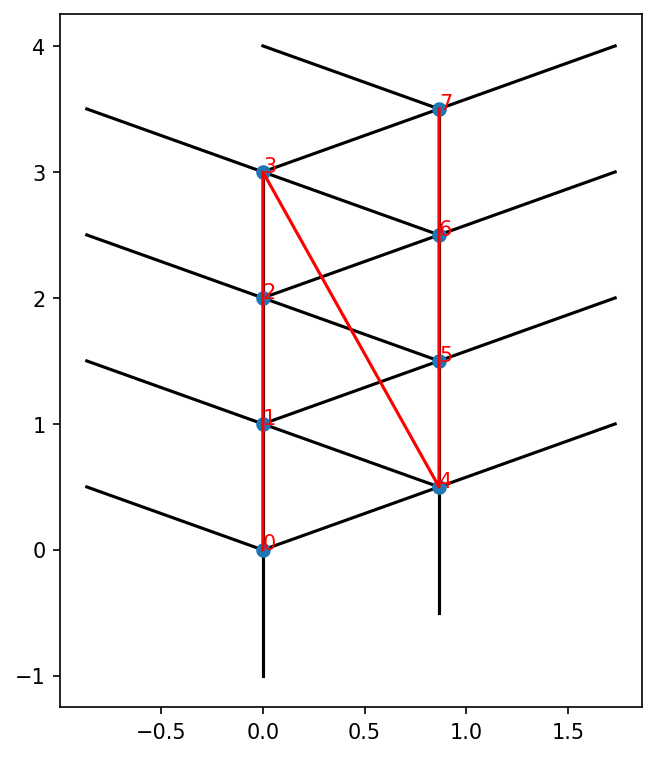

In [ ]:
model_params = {'lat_type': 'Triangular', 'Lx': 2, 'Ly': 4, 'Jz': 1.0, 'Jp': 1.0, "bc_MPS": "infinite", "bc_x": "periodic", "bc_y": -1}
dmrg_params = {'trunc_params': {'chi_max': 100, 'svd_min': 1.0e-10}, 'mixer': True, 'max_sweeps': 40}
N = 4  # number of sites in unit cell

#model_params: lat_type; J; g; order; Lx; Ly;
model = AnisotropicHeisenberg(model_params)
sites = model.lat.mps_sites() # create sites

#display lattice and chain
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 6))
ax = plt.gca()
model.lat.plot_coupling(ax)
model.lat.plot_sites(ax)
model.lat.plot_order(ax)
model.lat.plot_bc_shift(ax)
plt.show()

# Print the lattice order so you can see how MPS indices map to (x, y) positions
print("MPS index -> lattice position:")
for i, pos in enumerate(model.lat.order):
    print(f"  MPS {i} -> lat {pos} -> coords {model.lat.position(pos)}")

In [8]:
class ModTriangular(SimpleLattice):
    """Copied from the tenpy but changed basis"""
    dim = 2  #: the dimension of the lattice

    def __init__(self, Lx, Ly, site, **kwargs):
        sqrt3_half = 0.5 * np.sqrt(3)  # = cos(pi/6)
        basis = np.array([[1.0, 0], [0.5,  sqrt3_half]])
        NN = [(0, 0, np.array([1, 0])), (0, 0, np.array([-1, 1])), (0, 0, np.array([0, -1]))]
        nNN = [(0, 0, np.array([2, -1])), (0, 0, np.array([1, 1])), (0, 0, np.array([-1, 2]))]
        nnNN = [(0, 0, np.array([2, 0])), (0, 0, np.array([0, 2])), (0, 0, np.array([-2, 2]))]
        kwargs.setdefault('basis', basis)
        kwargs.setdefault('pairs', {})
        kwargs['pairs'].setdefault('nearest_neighbors', NN)
        kwargs['pairs'].setdefault('next_nearest_neighbors', nNN)
        kwargs['pairs'].setdefault('next_next_nearest_neighbors', nnNN)
        SimpleLattice.__init__(self, [Lx, Ly], site, **kwargs)

    def plot_coupling_correlations(self, ax, correlations, coupling=None, wrap=False,
                                cmap='viridis', vmin=None, vmax=None, value_func=np.abs,
                                linewidth=3, cbar=True, cbar_kwargs=None, **kwargs):
        """Plot lines connecting nearest neighbors, colored by a correlation matrix.

        Like :meth:`plot_coupling`, but instead of every bond having the same color, the bond
        connecting MPS site `i` to MPS site `j` is colored according to
        ``value_func(correlations[i, j])``, with a colorbar showing the mapping.

        Parameters
        ----------
        ax : :class:`matplotlib.axes.Axes`
            The axes on which we should plot.
        correlations : 2D array
            Correlation matrix as e.g. returned by
            :meth:`~tenpy.networks.mps.MPS.correlation_function`, with ``correlations[i, j]``
            the value for MPS sites `i`, `j`. Should have shape ``(self.N_sites, self.N_sites)``
            (i.e. cover (at least) one MPS unit cell). For an infinite lattice with ``wrap=True``,
            indices are taken mod ``self.N_sites``, which is correct as long as `correlations`
            is translation invariant by one unit cell.
        coupling : list of (u1, u2, dx)
            Same as in :meth:`plot_coupling`; defaults to ``self.pairs['nearest_neighbors']``.
        wrap : bool
            Same as in :meth:`plot_coupling`.
        cmap : str | Colormap
            Colormap mapping correlation values to colors.
        vmin, vmax : float | None
            Color scale limits; default to the data's min/max.
        value_func : callable
            Applied to the (possibly complex) correlation values before coloring,
            e.g. ``np.abs`` (default), ``np.real``, or ``lambda x: x``.
        linewidth : float
            Width of the plotted bonds (overridden by ``kwargs['linewidth']`` if given).
        cbar : bool
            Whether to attach a colorbar to `ax`.
        cbar_kwargs : dict | None
            Extra keyword arguments passed to ``ax.figure.colorbar``.
        **kwargs :
            Further keyword arguments given to :class:`~matplotlib.collections.LineCollection`.

        Returns
        -------
        lc : :class:`matplotlib.collections.LineCollection`
            The collection added to `ax` (e.g. for further tweaking with ``lc.set_array``).
        """
        if coupling is None:
            coupling = self.pairs['nearest_neighbors']
        correlations = np.asarray(correlations)
        Ls = np.array(self.Ls)
        N_sites = self.N_sites

        all_pos1, all_pos2, all_vals = [], [], []

        for u1, u2, dx in coupling:
            if wrap:
                mps_i, mps_j, _, _ = self.possible_couplings(u1, u2, dx)
                pos1 = self.position(self.mps2lat_idx(mps_i))
                pos2 = self.position(self.mps2lat_idx(mps_j))
                idx1 = np.mod(mps_i, N_sites)
                idx2 = np.mod(mps_j, N_sites)
            else:
                dx = np.r_[np.array(dx), u2 - u1]  # append the difference in u to dx
                lat_idx_1 = self.order[self._mps_fix_u[u1], :]
                lat_idx_2 = lat_idx_1 + dx[np.newaxis, :]
                lat_idx_2_mod = np.mod(lat_idx_2[:, :-1], Ls)
                keep = self._keep_possible_couplings(lat_idx_2_mod, lat_idx_2[:, :-1], u2)
                pos1 = self.position(lat_idx_1[keep, :])
                pos2 = self.position(lat_idx_2[keep, :])
                idx1 = self._mps_fix_u[u1][keep]
                lat_idx_2_mod_full = np.concatenate([lat_idx_2_mod, lat_idx_2[:, -1:]], axis=1)
                idx2 = self.lat2mps_idx(lat_idx_2_mod_full[keep])

            all_pos1.append(pos1)
            all_pos2.append(pos2)
            all_vals.append(correlations[idx1, idx2])

        pos1 = np.concatenate(all_pos1, axis=0)
        pos2 = np.concatenate(all_pos2, axis=0)
        vals = value_func(np.concatenate(all_vals, axis=0))

        if pos1.shape[1] == 1:
            pos1 = pos1 * np.array([[1.0, 0]])  # broadcast a zero column for 1D lattices
            pos2 = pos2 * np.array([[1.0, 0]])
        if pos1.shape[1] != 2:
            raise ValueError('can only plot in 2 dimensions.')

        segments = np.stack([pos1, pos2], axis=1)  # shape (N_bonds, 2, 2)

        kwargs.setdefault('linewidth', linewidth)
        lc = LineCollection(segments, cmap=cmap, **kwargs)
        lc.set_array(vals)
        if vmin is not None or vmax is not None:
            lc.set_clim(vmin, vmax)
        ax.add_collection(lc)
        ax.autoscale()

        if cbar:
            cbar_kwargs = dict(cbar_kwargs or {})
            cbar_kwargs.setdefault('ax', ax)
            ax.figure.colorbar(lc, **cbar_kwargs)
        return lc

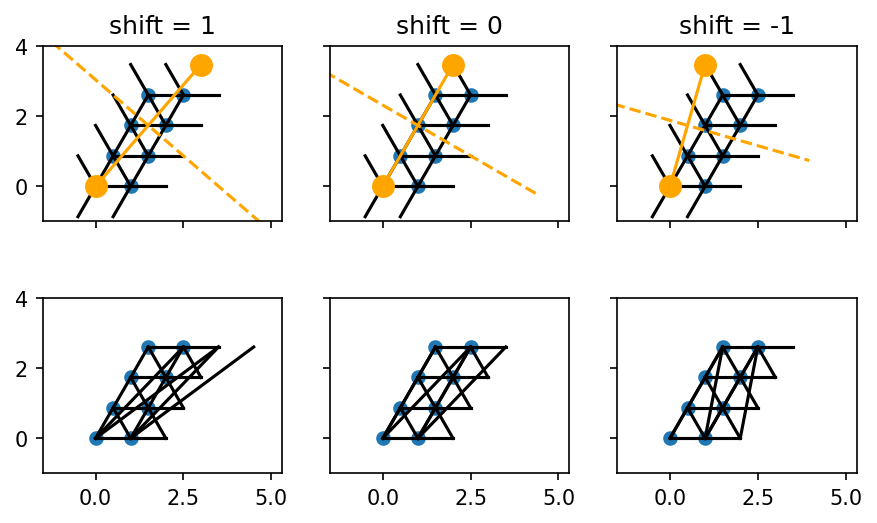

In [9]:
Lx, Ly = 2, 4
fig, axes = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(7, 4))

for i, shift in enumerate([1, 0, -1]):
    ax1, ax2 = axes[:, i]
    lat = ModTriangular(Lx, Ly, None, bc=['periodic', shift], bc_MPS='infinite')
    for ax in ax1, ax2:
        lat.plot_sites(ax)
        ax.set_aspect('equal')
        ax.set_ylim(-1, 4)
    lat.plot_coupling(ax1)
    lat.plot_bc_identified(ax1, cylinder_axis=True)
    lat.plot_coupling(ax2, wrap=True)
    ax1.set_title('shift = ' + str(shift))
    ax.set_xlim(-1.5)

plt.show()